In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [ ]:
data=pd.read_csv('data/data.csv')
data.head()

,Unnamed: 0,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,2093518,a3e3cea9f2e314,c9f6eaa81245b5,a3d8693390584c,0,0,25.93,0,0,0,...,0,0.0,0,0.0,0,0,151.30,1,1525,0.0667
1,3701672,43e4be7ad72cc7,521836de101ee8,b65de9055327e0,0,0,36.71,0,0,0,...,0,0.0,0,0.0,0,0,1918.00,7,1516,0.5862
2,2059784,9a68690e31fdff,4a72ffa2cebd90,d6aad3f9830e60,0,1,47.73,0,0,0,...,0,4088.0,0,0.0,0,0,820.00,7,0,0.8105
3,1302036,b147e1bd448fc4,9a8991656b3fea,d931c0932d8aca,0,0,0.00,0,0,0,...,1,0.0,0,0.0,0,0,38.81,0,1515,0.5556
4,297180,d818b4edd59612,eece87c8b846b3,ec2b5ed94baae3,0,2,100.00,0,0,3,...,0,918.4,0,0.0,0,0,1721.00,5,0,0.6429


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1111742 entries, 0 to 1111741
Data columns (total 30 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1111742 non-null  int64  
 1   Id               1111742 non-null  object 
 2   groupId          1111742 non-null  object 
 3   matchId          1111742 non-null  object 
 4   assists          1111742 non-null  int64  
 5   boosts           1111742 non-null  int64  
 6   damageDealt      1111742 non-null  float64
 7   DBNOs            1111742 non-null  int64  
 8   headshotKills    1111742 non-null  int64  
 9   heals            1111742 non-null  int64  
 10  killPlace        1111742 non-null  int64  
 11  killPoints       1111742 non-null  int64  
 12  kills            1111742 non-null  int64  
 13  killStreaks      1111742 non-null  int64  
 14  longestKill      1111742 non-null  float64
 15  matchDuration    1111742 non-null  int64  
 16  matchType        1

In [4]:
print(data.shape)
data.describe()

(1111742, 30)


,Unnamed: 0,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,...,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111742e+06,1.111741e+06
mean,2.224362e+06,2.336738e-01,1.106655e+00,1.307364e+02,6.573612e-01,2.266488e-01,1.370348e+00,4.759562e+01,5.044301e+02,9.255097e-01,...,1.641784e-01,6.042142e+02,3.551184e-03,4.545068e+00,2.401097e-02,7.833652e-03,1.153282e+03,3.659685e+00,6.057065e+02,4.727868e-01
std,1.283879e+06,5.894028e-01,1.716050e+00,1.711755e+02,1.146023e+00,6.033356e-01,2.683819e+00,2.747025e+01,6.274006e+02,1.562216e+00,...,4.704189e-01,1.495949e+03,7.385452e-02,3.061857e+01,1.678909e-01,9.194621e-02,1.182788e+03,2.461805e+00,7.395140e+02,3.073771e-01
min,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.112440e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.552000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,2.223772e+06,0.000000e+00,0.000000e+00,8.411000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.841000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,3.337954e+06,0.000000e+00,2.000000e+00,1.859000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.171000e+03,1.000000e+00,...,0.000000e+00,7.927500e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.975000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,4.446964e+06,1.700000e+01,2.400000e+01,5.990000e+03,3.500000e+01,6.400000e+01,7.300000e+01,1.000000e+02,2.170000e+03,7.200000e+01,...,2.300000e+01,3.540000e+04,1.400000e+01,2.668000e+03,1.000000e+01,5.000000e+00,1.396000e+04,1.770000e+02,2.002000e+03,1.000000e+00


# Reading Data Using its statistical  data Analysis

##### >> Average damage dealt is 131, but the max is a massive 5,990 — most players deal moderate damage while a few are extremely lethal
##### >> Average kills are only 0.93 with a median of 0 — meaning most players die without getting a kill.
##### >> Headshot rate is low (mean ~0.27), indicating most kills aren't headshots

###### > Average walk distance is 1,153 meters, maxing out at 13,960m — huge variation in how far players roam
###### > Ride distance averages ~604m, max 35,400m — some players are very vehicle-heavy

##### >> Heals average ~47.6 with a max of 100 (capped stat)
##### >> Boosts average ~1.1; assists ~0.23 — most players don't play support roles
##### >> Revives average only ~0.16 — teammate reviving is rare






In [5]:
data.columns

Index(['Unnamed: 0', 'Id', 'groupId', 'matchId', 'assists', 'boosts',
       'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace',
       'killPoints', 'kills', 'killStreaks', 'longestKill', 'matchDuration',
       'matchType', 'maxPlace', 'numGroups', 'rankPoints', 'revives',
       'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
       'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
       'winPlacePerc'],
      dtype='object')

In [6]:
data.isna().sum()

Unnamed: 0         0
Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       1
dtype: int64

<Axes: xlabel='winPlacePerc', ylabel='Count'>

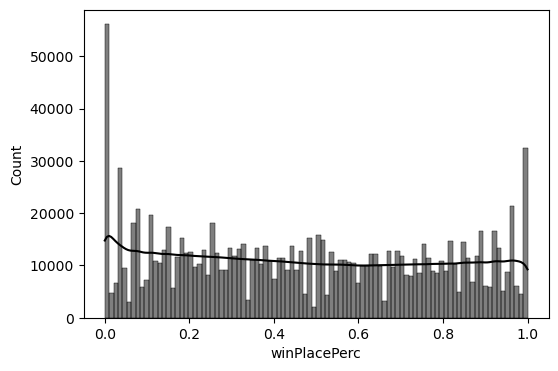

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(data,x='winPlacePerc',kde=True,color='black')

In [8]:
data["winPlacePerc"]=data["winPlacePerc"].fillna(data["winPlacePerc"].median())

In [9]:
data.isna().sum()

Unnamed: 0         0
Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       0
dtype: int64

In [10]:
train_data=data.drop(['Id','Unnamed: 0','groupId','matchId'],axis=1)

In [11]:
train_data.columns

Index(['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals',
       'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill',
       'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints',
       'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills',
       'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints',
       'winPlacePerc'],
      dtype='object')

In [12]:
df=train_data
print(df.describe().T.to_string())

                     count         mean          std  min     25%        50%          75%      max
assists          1111742.0     0.233674     0.589403  0.0     0.0     0.0000     0.000000     17.0
boosts           1111742.0     1.106655     1.716050  0.0     0.0     0.0000     2.000000     24.0
damageDealt      1111742.0   130.736407   171.175538  0.0     0.0    84.1100   185.900000   5990.0
DBNOs            1111742.0     0.657361     1.146023  0.0     0.0     0.0000     1.000000     35.0
headshotKills    1111742.0     0.226649     0.603336  0.0     0.0     0.0000     0.000000     64.0
heals            1111742.0     1.370348     2.683819  0.0     0.0     0.0000     2.000000     73.0
killPlace        1111742.0    47.595622    27.470247  1.0    24.0    47.0000    71.000000    100.0
killPoints       1111742.0   504.430117   627.400616  0.0     0.0     0.0000  1171.000000   2170.0
kills            1111742.0     0.925510     1.562216  0.0     0.0     0.0000     1.000000     72.0
killStreak

In [13]:
print("\n Target (winPlacePerc) distribution:")
print(df["winPlacePerc"].describe())


 Target (winPlacePerc) distribution:
count    1.111742e+06
mean     4.727868e-01
std      3.073770e-01
min      0.000000e+00
25%      2.000000e-01
50%      4.583000e-01
75%      7.407000e-01
max      1.000000e+00
Name: winPlacePerc, dtype: float64


In [14]:
numeric_df = df.select_dtypes(include=[np.number])
target_corr = (
    numeric_df.corr()["winPlacePerc"]
    .drop("winPlacePerc")
    .sort_values(ascending=False)
)
print("\nTop 10 features correlated with winPlacePerc:")
print(target_corr.head(10).to_string())
print("\n[1.7] Bottom 5 (negative correlation):")
print(target_corr.tail(5).to_string())



Top 10 features correlated with winPlacePerc:
walkDistance       0.810816
boosts             0.633482
weaponsAcquired    0.582504
damageDealt        0.438973
heals              0.427296
kills              0.418527
longestKill        0.408853
killStreaks        0.376840
rideDistance       0.343015
assists            0.297738

[1.7] Bottom 5 (negative correlation):
rankPoints       0.013496
killPoints       0.013089
winPoints        0.007290
matchDuration   -0.005709
killPlace       -0.719050


In [15]:
print("\nPotential Outliers (values > mean + 5*std):")
for col in ["kills", "damageDealt", "walkDistance", "killPoints"]:
    if col in df.columns:
        threshold = df[col].mean() + 5 * df[col].std()
        outlier_count = (df[col] > threshold).sum()
        print(f"  {col}: {outlier_count:,} outliers (> {threshold:.1f})")


Potential Outliers (values > mean + 5*std):
  kills: 5,209 outliers (> 8.7)
  damageDealt: 4,190 outliers (> 986.6)
  walkDistance: 560 outliers (> 7067.2)
  killPoints: 0 outliers (> 3641.4)


In [16]:
if 'matchType' in df.columns:
    display(df['matchType'].value_counts().to_frame('Count'))
else:
    print("matchType column not found")

,Count
matchType,
squad-fpp,438781
duo-fpp,249927
squad,156573
solo-fpp,133854
duo,78039
solo,45679
normal-squad-fpp,4286
crashfpp,1581
normal-duo-fpp,1400


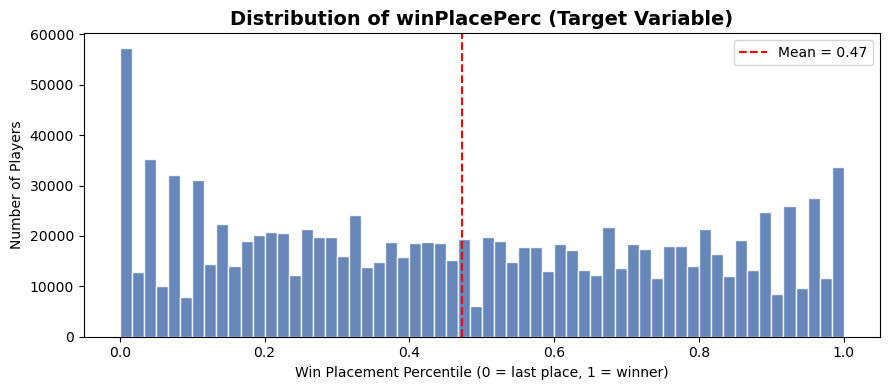

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['winPlacePerc'].dropna(), bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of winPlacePerc (Target Variable)', fontsize=14, fontweight='bold')
ax.set_xlabel('Win Placement Percentile (0 = last place, 1 = winner)')
ax.set_ylabel('Number of Players')
ax.axvline(df['winPlacePerc'].mean(), color='red', linestyle='--', label=f"Mean = {df['winPlacePerc'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

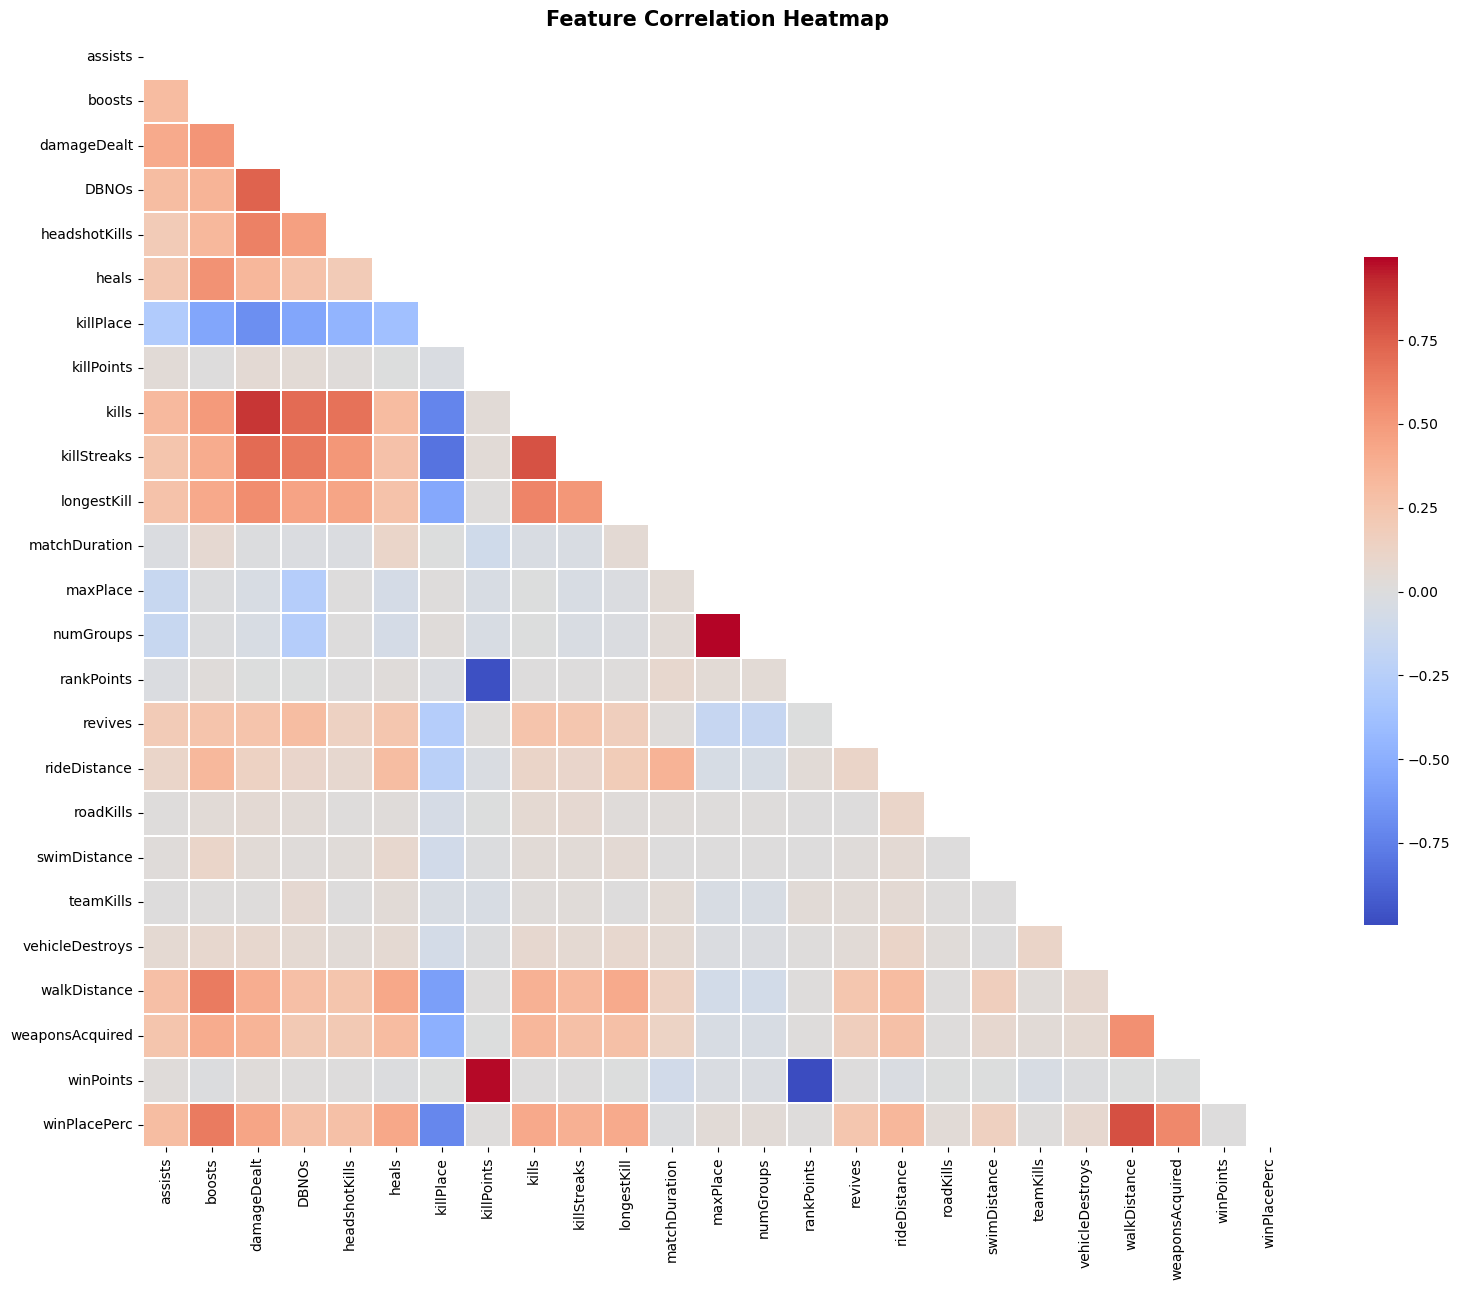

In [18]:
fig, ax = plt.subplots(figsize=(16, 13))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='coolwarm', linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

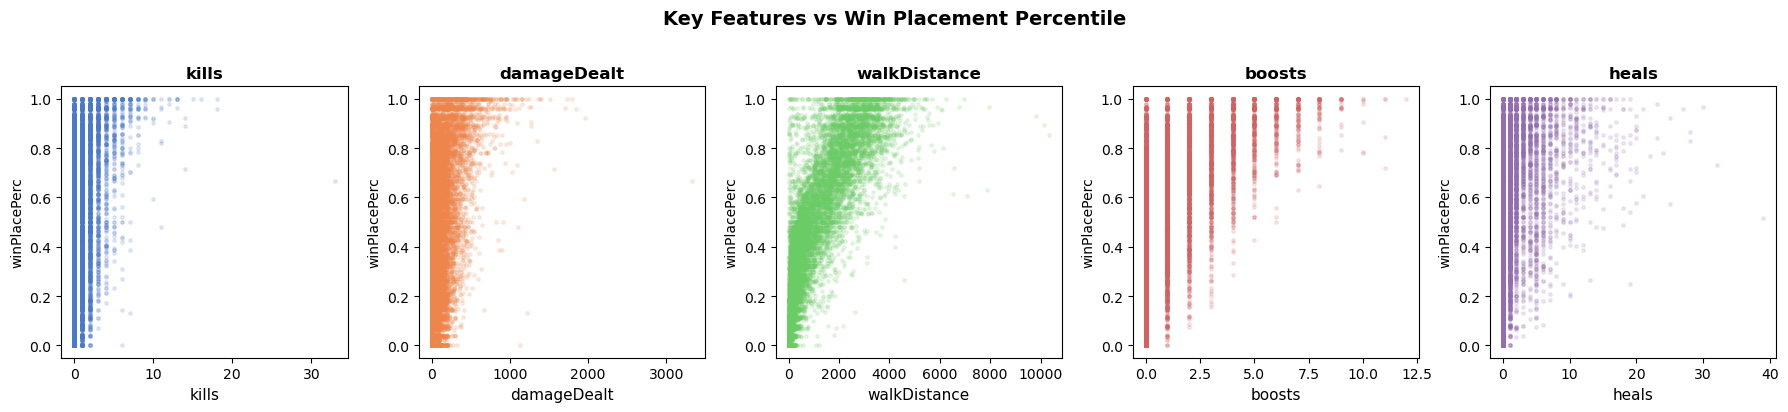

In [19]:
top_features = ['kills', 'damageDealt', 'walkDistance', 'boosts', 'heals']
top_features = [f for f in top_features if f in df.columns]
sample = df.sample(min(10000, len(df)), random_state=42)

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))
colors = sns.color_palette('muted', len(top_features))
for ax, feat, color in zip(axes, top_features, colors):
    ax.scatter(sample[feat], sample['winPlacePerc'], alpha=0.15, s=6, color=color)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('winPlacePerc')
    ax.set_title(f'{feat}', fontweight='bold')
plt.suptitle('Key Features vs Win Placement Percentile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

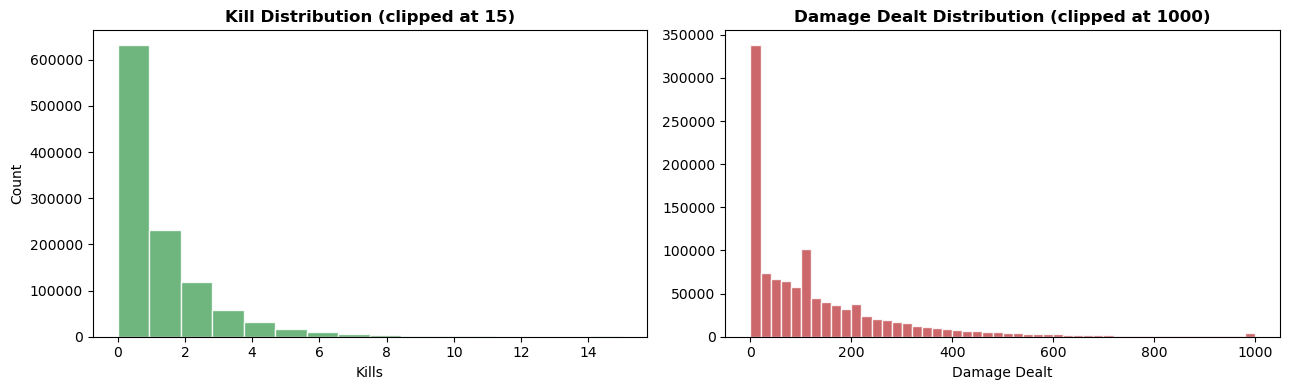

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['kills'].clip(0, 15), bins=16, color='#55A868', edgecolor='white', alpha=0.85)
axes[0].set_title('Kill Distribution (clipped at 15)', fontweight='bold')
axes[0].set_xlabel('Kills')
axes[0].set_ylabel('Count')

axes[1].hist(df['damageDealt'].clip(0, 1000), bins=50, color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].set_title('Damage Dealt Distribution (clipped at 1000)', fontweight='bold')
axes[1].set_xlabel('Damage Dealt')

plt.tight_layout()
plt.show()

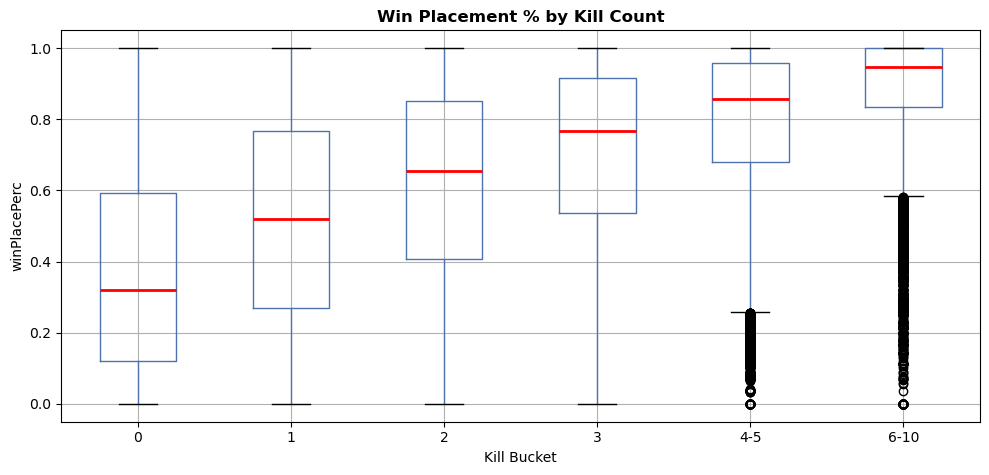

In [21]:
# 3.5 Kills vs Win Placement Boxplot
kill_buckets = df.copy()
kill_buckets['kill_bucket'] = pd.cut(
    kill_buckets['kills'].clip(0, 10),
    bins=[-1, 0, 1, 2, 3, 5, 10],
    labels=['0', '1', '2', '3', '4-5', '6-10']
)

fig, ax = plt.subplots(figsize=(10, 5))
kill_buckets.boxplot(column='winPlacePerc', by='kill_bucket', ax=ax,
                     boxprops=dict(color='#4C72B0'),
                     whiskerprops=dict(color='#4C72B0'),
                     medianprops=dict(color='red', linewidth=2))
ax.set_title('Win Placement % by Kill Count', fontweight='bold')
ax.set_xlabel('Kill Bucket')
ax.set_ylabel('winPlacePerc')
plt.suptitle('')
plt.tight_layout()
plt.show()

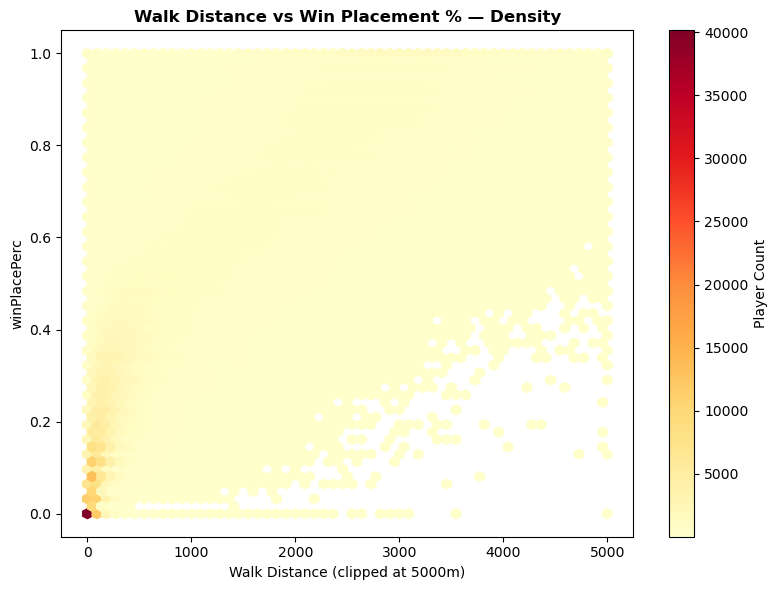

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    df['walkDistance'].clip(0, 5000),
    df['winPlacePerc'],
    gridsize=55, cmap='YlOrRd', mincnt=1
)
fig.colorbar(hb, ax=ax, label='Player Count')
ax.set_xlabel('Walk Distance (clipped at 5000m)')
ax.set_ylabel('winPlacePerc')
ax.set_title('Walk Distance vs Win Placement % — Density', fontweight='bold')
plt.tight_layout()
plt.show()

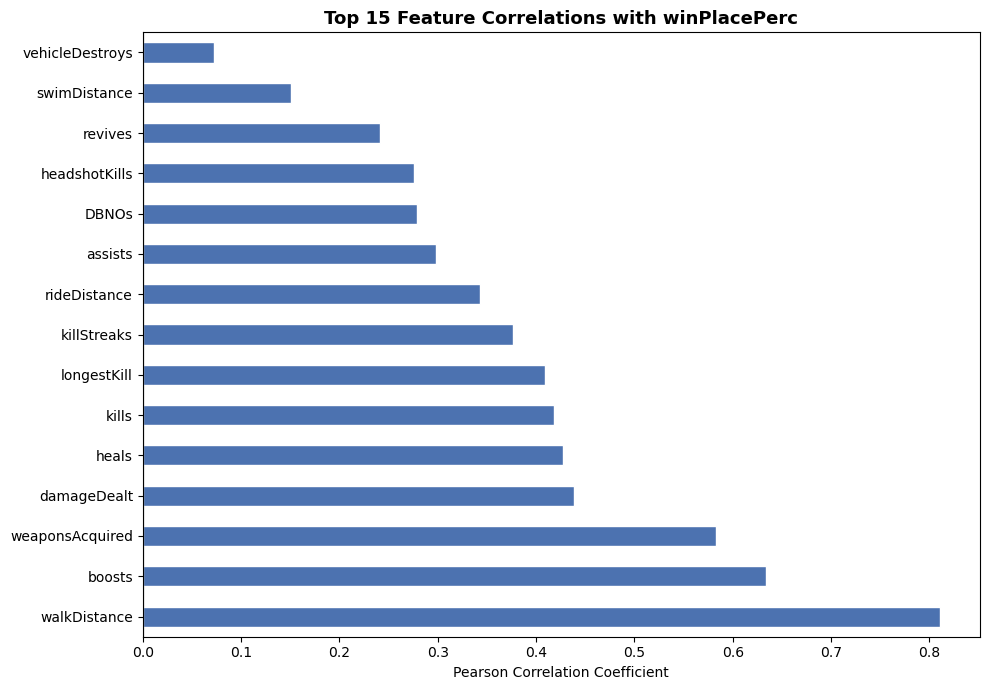

In [23]:
# 3.7 Feature Correlation with Target (bar chart)
fig, ax = plt.subplots(figsize=(10, 7))
top_corr = target_corr.head(15)
colors = ['#4C72B0' if v > 0 else '#C44E52' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 15 Feature Correlations with winPlacePerc', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [24]:
#for i in df['kills']:
a=max(df['kills'])
print("Maximum Number of Kills : ",a)
b=max(df['assists'])
print("Maximum Number of Assists : ",b)

Maximum Number of Kills :  72
Maximum Number of Assists :  17


In [25]:
df_model = df.copy()

# Drop rows with missing target
df_model = df_model.dropna(subset=['winPlacePerc'])

# Engineered features
df_model['totalDistance']  = df_model.get('walkDistance', 0) + df_model.get('rideDistance', 0) + df_model.get('swimDistance', 0)
df_model['healsAndBoosts'] = df_model.get('heals', 0) + df_model.get('boosts', 0)
df_model['killsNorm']      = df_model['kills'] / (df_model['maxPlace'].replace(0, 1))
df_model['damagePerKill']  = np.where(df_model['kills'] > 0, df_model['damageDealt'] / df_model['kills'], 0)
df_model['headshotRate']   = np.where(df_model['kills'] > 0, df_model['headshotKills'] / df_model['kills'], 0)
df_model['isSniper']       = (df_model['longestKill'] > 100).astype(int)

# Drop non-numeric / ID columns
drop_cols = ['Id', 'groupId', 'matchId', 'matchType', 'Unnamed: 0']
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], errors='ignore')

print(f"Features after engineering: {df_model.shape[1]}")
print("New features added: totalDistance, healsAndBoosts, killsNorm, damagePerKill, headshotRate, isSniper")
df_model.head(10)


Features after engineering: 31
New features added: totalDistance, healsAndBoosts, killsNorm, damagePerKill, headshotRate, isSniper


,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,walkDistance,weaponsAcquired,winPoints,winPlacePerc,totalDistance,healsAndBoosts,killsNorm,damagePerKill,headshotRate,isSniper
0,0,0,25.93,0,0,0,84,1437,0,0,...,151.30,1,1525,0.0667,151.30,0,0.000000,0.000000,0.0,0
1,0,0,36.71,0,0,0,57,1225,0,0,...,1918.00,7,1516,0.5862,1918.00,0,0.000000,0.000000,0.0,0
2,0,1,47.73,0,0,0,50,0,0,0,...,820.00,7,0,0.8105,4908.00,1,0.000000,0.000000,0.0,0
3,0,0,0.00,0,0,0,56,1286,0,0,...,38.81,0,1515,0.5556,38.81,0,0.000000,0.000000,0.0,0
4,0,2,100.00,0,0,3,31,0,1,1,...,1721.00,5,0,0.6429,2639.40,5,0.010101,100.000000,0.0,0
5,0,0,0.00,0,0,0,59,0,0,0,...,446.00,3,0,0.4946,446.00,0,0.000000,0.000000,0.0,0
6,0,0,0.00,0,0,0,81,0,0,0,...,45.86,1,0,0.1939,45.86,0,0.000000,0.000000,0.0,0
7,0,8,170.20,0,0,1,25,0,1,1,...,3297.00,5,0,0.9688,3518.00,9,0.010309,170.200000,0.0,0
8,0,2,338.70,2,0,15,6,0,4,2,...,1846.00,5,0,0.7174,5195.00,17,0.085106,84.675000,0.0,0
9,2,1,230.80,2,0,1,8,0,3,2,...,3781.00,5,0,0.8387,3781.00,2,0.093750,76.933333,0.0,1


In [26]:
TARGET = 'winPlacePerc'
feature_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != TARGET]

X = df_model[feature_cols].fillna(0)
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Features: {len(feature_cols)}")

Train: 889,393 rows | Test: 222,349 rows
Features: 30


In [ ]:
df_model.head(4)
# TEST CASE

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,walkDistance,weaponsAcquired,winPoints,winPlacePerc,totalDistance,healsAndBoosts,killsNorm,damagePerKill,headshotRate,isSniper
0,0,0,25.93,0,0,0,84,1437,0,0,...,151.30,1,1525,0.0667,151.30,0,0.0,0.0,0.0,0
1,0,0,36.71,0,0,0,57,1225,0,0,...,1918.00,7,1516,0.5862,1918.00,0,0.0,0.0,0.0,0
2,0,1,47.73,0,0,0,50,0,0,0,...,820.00,7,0,0.8105,4908.00,1,0.0,0.0,0.0,0
3,0,0,0.00,0,0,0,56,1286,0,0,...,38.81,0,1515,0.5556,38.81,0,0.0,0.0,0.0,0
